# 03 · Goal Shooting / Penales

Entrenamiento tabular en un entorno simplificado de **un disparo por episodio**. Se estudian el arco abierto y el portero activo. El modelo de esta sección se reproduce tal como fue proporcionado; la animación posterior solo representa los datos del disparo.


In [1]:
import math
import time
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from IPython.display import clear_output, display

np.random.seed(42)

## 1. Formalización del MDP y entorno

- **Estado observado:** distancia al centro del arco, ángulos relativos a ambos postes y sector del portero (0 indica arco abierto). Los cortes del código producen hasta $4\times3\times3\times4=144$ estados discretos, aunque no todos son alcanzables desde el inicio definido.
- **Acciones:** nueve combinaciones de `KICK(power, sector)`, con potencias 50, 75 y 100 y sectores izquierdo, central y derecho.
- **Transición:** tras elegir una acción se obtiene el resultado estocástico del tiro y termina el episodio. El siguiente estado devuelto por `step` es terminal; los algoritmos no hacen bootstrap desde él.
- **Recompensa:** +100 por gol, −30 por disparo desviado y −50 por bloqueo.
- **Descuento:** $\gamma=0.99$ como parámetro del experimento; no modifica el retorno de un episodio de un paso.

Las tasas objetivo del enunciado son **más de 75 %** con arco abierto y **más de 50 %** con portero activo. El modelo siguiente es el entorno simplificado adjuntado, sin cambios en sus reglas.


In [ ]:
class GoalShootingSimEnv:
    """
    Entorno simplificado para Goal Shooting / Penales.

    Estado:
        (
            goal_distance_bin,
            left_post_angle_bin,
            right_post_angle_bin,
            goalkeeper_sector
        )

    Acciones:
        KICK(power, sector)

        power  = {50, 75, 100}
        sector = {LEFT, CENTER, RIGHT}

    => 3 x 3 = 9 acciones discretas.

    Cada episodio corresponde a un disparo.
    """

    def __init__(self, goalkeeper_active=True):

        self.goalkeeper_active = goalkeeper_active

        # Geometría del arco rival
        self.goal_x = 52.5

        self.left_post_y = 7.0
        self.right_post_y = -7.0

        # Acciones discretas
        self.powers = [50, 75, 100]

        self.target_sectors = {
            0: 5.0,  # sector izquierdo
            1: 0.0,  # centro
            2: -5.0,  # sector derecho
        }

        self.reset()

    # ============================================================
    # RESET
    # ============================================================

    def reset(self):

        # Delantero frente al arco
        self.player_x = np.random.uniform(25.0, 40.0)
        self.player_y = np.random.uniform(-10.0, 10.0)

        # Orientación aproximadamente hacia el arco
        angle_to_goal = math.degrees(
            math.atan2(-self.player_y, self.goal_x - self.player_x)
        )

        self.player_theta = angle_to_goal + np.random.uniform(-15.0, 15.0)

        # Portero
        if self.goalkeeper_active:

            # Cerca de la línea de gol
            self.goalkeeper_x = 50.5

            # Puede empezar desplazado lateralmente
            self.goalkeeper_y = np.random.uniform(-6.0, 6.0)

        else:
            self.goalkeeper_x = None
            self.goalkeeper_y = None

        self.done = False

        return self._get_state()

    # ============================================================
    # OBSERVACIONES POLARES
    # ============================================================

    def _relative_polar(self, object_x, object_y):

        dx = object_x - self.player_x
        dy = object_y - self.player_y

        dist = math.hypot(dx, dy)

        global_angle = math.degrees(math.atan2(dy, dx))

        relative_angle = (global_angle - self.player_theta + 180.0) % 360.0 - 180.0

        return dist, relative_angle

    def _get_obs(self):

        # Centro del arco
        goal_dist, _ = self._relative_polar(self.goal_x, 0.0)

        # Poste izquierdo
        _, left_angle = self._relative_polar(self.goal_x, self.left_post_y)

        # Poste derecho
        _, right_angle = self._relative_polar(self.goal_x, self.right_post_y)

        return (goal_dist, left_angle, right_angle)

    # ============================================================
    # DISCRETIZACIÓN
    # ============================================================

    def _goal_distance_bin(self, dist):

        if dist < 15:
            return 0
        elif dist < 25:
            return 1
        elif dist < 35:
            return 2
        else:
            return 3

    def _angle_bin(self, angle):

        if angle < -15:
            return 0

        elif angle <= 15:
            return 1

        else:
            return 2

    def _goalkeeper_bin(self):

        if not self.goalkeeper_active:
            return 0  # no goalkeeper

        if self.goalkeeper_y > 2:
            return 1  # izquierda

        elif self.goalkeeper_y < -2:
            return 3  # derecha

        else:
            return 2  # centro

    def _discretize(self, goal_dist, left_angle, right_angle):

        return (
            self._goal_distance_bin(goal_dist),
            self._angle_bin(left_angle),
            self._angle_bin(right_angle),
            self._goalkeeper_bin(),
        )

    def _get_state(self):

        obs = self._get_obs()

        return self._discretize(*obs)

    # ============================================================
    # DECODIFICACIÓN DE LA ACCIÓN
    # ============================================================

    def _decode_action(self, action):
        """
        action ∈ [0, 8]

        0,1,2 -> power 50
        3,4,5 -> power 75
        6,7,8 -> power 100
        """

        power_index = action // 3
        sector_index = action % 3

        power = self.powers[power_index]

        target_y = self.target_sectors[sector_index]

        return power, sector_index, target_y

    # ============================================================
    # STEP
    # ============================================================

    def step(self, action):

        if self.done:
            raise RuntimeError("El episodio terminó. Debes ejecutar reset().")

        power, sector, target_y = self._decode_action(action)

        # --------------------------------------------------------
        # Dirección del disparo
        # --------------------------------------------------------

        dx = self.goal_x - self.player_x
        dy = target_y - self.player_y

        shot_global_angle = math.degrees(math.atan2(dy, dx))

        kick_direction = (shot_global_angle - self.player_theta + 180) % 360 - 180

        # --------------------------------------------------------
        # Ruido del disparo
        # --------------------------------------------------------

        # Más potencia -> un poco más de variabilidad
        noise_std = 1.0 + 0.02 * power

        shot_y = target_y + np.random.normal(0.0, noise_std)

        # --------------------------------------------------------
        # ¿El disparo entra dentro del arco?
        # --------------------------------------------------------

        inside_goal = self.right_post_y <= shot_y <= self.left_post_y

        # --------------------------------------------------------
        # ¿Lo bloquea el portero?
        # --------------------------------------------------------

        blocked = False

        if self.goalkeeper_active and inside_goal:

            goalkeeper_reach = 1.5

            if abs(shot_y - self.goalkeeper_y) <= goalkeeper_reach:

                blocked = True

        # ========================================================
        # REWARD
        # ========================================================

        if not inside_goal:

            reward = -30.0
            result = "miss"

        elif blocked:

            reward = -50.0
            result = "blocked"

        else:

            reward = 100.0
            result = "goal"

        self.done = True

        # El siguiente estado realmente ya no importa porque
        # el episodio termina tras el disparo.
        next_state = self._get_state()

        info = {
            "result": result,
            "goal": result == "goal",
            "blocked": blocked,
            "power": power,
            "sector": sector,
            "kick_direction": kick_direction,
            "shot_y": shot_y,
            "goalkeeper_y": self.goalkeeper_y,
        }

        return (next_state, reward, True, info)


print("Clase GoalShootingSimEnv definida correctamente.")

Clase GoalShootingSimEnv definida correctamente.


## 2. Control tabular

`train_control` acepta los nombres Monte Carlo Control First-Visit, SARSA, Expected SARSA y Q-Learning. Como cada episodio termina tras un solo tiro, no existe un siguiente estado no terminal desde el que actualizar: SARSA, Expected SARSA y Q-Learning comparten exactamente la misma actualización con la recompensa inmediata. Monte Carlo promedia las muestras de cada par estado-acción; los tres métodos TD aplican su tasa de aprendizaje $\alpha$. Por ello, este entorno no permite comparar las diferencias propias de esos tres algoritmos. Se comparan exploración $\varepsilon$ constante y decreciente.


In [7]:
ALGORITHMS = ("mc", "sarsa", "expected_sarsa", "q_learning")
ALGORITHM_NAMES = {
    "mc": "Monte Carlo",
    "sarsa": "SARSA",
    "expected_sarsa": "Expected SARSA",
    "q_learning": "Q-Learning",
}


def epsilon_greedy_policy(Q, state, n_actions, epsilon):
    if np.random.random() < epsilon:
        return int(np.random.randint(n_actions))
    values = Q[state]
    return int(np.random.choice(np.flatnonzero(values == values.max())))


def train_control(
    env,
    algorithm,
    n_episodes=2000,
    alpha=0.1,
    gamma=0.99,
    epsilon_mode="decay",
    epsilon=0.1,
    eps_start=1.0,
    eps_min=0.05,
    eps_decay=0.998,
    on_checkpoint=None,
):
    if algorithm not in ALGORITHMS:
        raise ValueError(f"Algoritmo desconocido: {algorithm}")
    if epsilon_mode not in ("constant", "decay"):
        raise ValueError("epsilon_mode debe ser 'constant' o 'decay'")
    n_actions = len(env.powers) * len(env.target_sectors)
    Q = defaultdict(lambda: np.zeros(n_actions, dtype=float))
    counts = defaultdict(lambda: np.zeros(n_actions, dtype=int))
    history = {"g0": [], "success": [], "steps": [], "epsilon": [], "states": []}

    for episode in range(n_episodes):
        eps = (
            epsilon
            if epsilon_mode == "constant"
            else max(eps_min, eps_start * eps_decay**episode)
        )
        state = env.reset()
        action = epsilon_greedy_policy(Q, state, n_actions, eps)
        next_state, reward, done, info = env.step(action)

        # El disparo termina el episodio. No se utiliza Q(next_state).
        if algorithm == "mc":
            counts[state][action] += 1
            Q[state][action] += (reward - Q[state][action]) / counts[state][action]
        else:
            Q[state][action] += alpha * (reward - Q[state][action])

        history["g0"].append(reward)
        history["success"].append(int(info["goal"]))
        history["steps"].append(1)
        history["epsilon"].append(eps)
        history["states"].append(state)
        if on_checkpoint is not None:
            on_checkpoint(episode, env, action, info, history)

    return dict(Q), history

### 2.1 Visualización durante el entrenamiento

En cada episodio seleccionado, la estrella marca el sector elegido de la portería. El balón avanza en fotogramas desde el jugador hasta el punto de llegada de este modelo; en un bloqueo se detiene a la altura del portero. La curva inferior derecha muestra la tasa de gol móvil, ya que la duración es siempre un paso.


In [8]:
def shot_endpoint(env, info):
    x = env.goalkeeper_x if info["blocked"] else env.goal_x
    return x, info["shot_y"]


def draw_shot(ax, env, info, action):
    ax.set_facecolor("#2e7d32")
    ax.add_patch(
        patches.Rectangle(
            (20, -15), 32.5, 30, edgecolor="white", facecolor="none", linewidth=1.4
        )
    )
    ax.add_patch(
        patches.Rectangle(
            (36, -20.16), 16.5, 40.32, edgecolor="white", facecolor="none"
        )
    )
    ax.add_patch(
        patches.Rectangle(
            (env.goal_x, env.right_post_y),
            2,
            env.left_post_y - env.right_post_y,
            edgecolor="yellow",
            facecolor="none",
            linewidth=2,
        )
    )
    ax.plot(
        env.player_x, env.player_y, "^", color="#29b6f6", markersize=11, label="Jugador"
    )
    if env.goalkeeper_active:
        ax.plot(
            env.goalkeeper_x,
            env.goalkeeper_y,
            "s",
            color="#f44336",
            markersize=10,
            label="Portero",
        )
    sector = info["sector"]
    target_y = env.target_sectors[sector]
    ax.plot(
        env.goal_x, target_y, "*", color="yellow", markersize=14, label="Sector elegido"
    )
    end_x, end_y = shot_endpoint(env, info)
    ax.plot(end_x, end_y, "x", color="white", markersize=10, label="Llegada del tiro")
    (path,) = ax.plot([], [], color="#ffca28", linewidth=2, label="Recorrido del balón")
    (ball,) = ax.plot(
        [], [], "o", color="#ffca28", markersize=10, markeredgecolor="black"
    )
    ax.set_xlim(20, 56)
    y_limit = max(15, abs(end_y) + 2)
    ax.set_ylim(-y_limit, y_limit)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.legend(loc="upper left", fontsize=8)
    return path, ball


def moving_average(values, window=50):
    values = np.asarray(values, dtype=float)
    width = min(window, len(values))
    return np.convolve(values, np.ones(width) / width, mode="valid")


def train_visual(
    env,
    algorithm,
    n_episodes=2000,
    render_every=500,
    frames=8,
    frame_delay=0.04,
    **training_options,
):
    """Entrena y anima cada tiro seleccionado sin modificar el entorno."""
    if render_every < 1 or frames < 2 or frame_delay < 0:
        raise ValueError("render_every y frames deben ser positivos; frame_delay >= 0")

    def render(episode, shot_env, action, info, history):
        if episode != 0 and (episode + 1) % render_every and episode + 1 != n_episodes:
            return
        clear_output(wait=True)
        fig = plt.figure(figsize=(13, 5.5))
        grid = fig.add_gridspec(2, 2, width_ratios=(1.4, 1))
        ax_pitch = fig.add_subplot(grid[:, 0])
        ax_return = fig.add_subplot(grid[0, 1])
        ax_success = fig.add_subplot(grid[1, 1])
        path, ball = draw_shot(ax_pitch, shot_env, info, action)
        outcome = {"goal": "GOL", "miss": "DESVIADO", "blocked": "BLOQUEADO"}[
            info["result"]
        ]
        ax_pitch.set_title(
            f"{ALGORITHM_NAMES[algorithm]} · episodio {episode + 1}/{n_episodes} · {outcome}"
        )
        for ax, key, title, color in (
            (ax_return, "g0", "Retorno G₀", "#1f77b4"),
            (ax_success, "success", "Tasa de gol móvil", "#2ca02c"),
        ):
            values = history[key]
            average = moving_average(values)
            first = len(values) - len(average)
            ax.plot(values, color=color, alpha=0.18)
            ax.plot(range(first, len(values)), average, color=color, linewidth=2)
            ax.set_title(title)
            ax.set_xlabel("Episodio")
            ax.grid(alpha=0.25)
        ax_success.set_ylim(-0.05, 1.05)
        fig.tight_layout()

        end_x, end_y = shot_endpoint(shot_env, info)
        handle = None
        for fraction in np.linspace(0, 1, frames):
            xs = np.linspace(shot_env.player_x, end_x, frames)
            ys = np.linspace(shot_env.player_y, end_y, frames)
            visible = max(1, int(round(fraction * (frames - 1))) + 1)
            path.set_data(xs[:visible], ys[:visible])
            ball.set_data([xs[visible - 1]], [ys[visible - 1]])
            if handle is None:
                handle = display(fig, display_id=True)
            else:
                handle.update(fig)
            if frame_delay:
                time.sleep(frame_delay)
        plt.close(fig)

    return train_control(
        env, algorithm, n_episodes=n_episodes, on_checkpoint=render, **training_options
    )

## 3. Entrenamiento en ambos escenarios

Se entrenan los cuatro algoritmos con exploración constante y decreciente en arco abierto y con portero. `train_visual` anima los episodios seleccionados de la modalidad decreciente con portero. Los porcentajes de éxito se calculan después, sin presuponer que se alcanzan los objetivos.


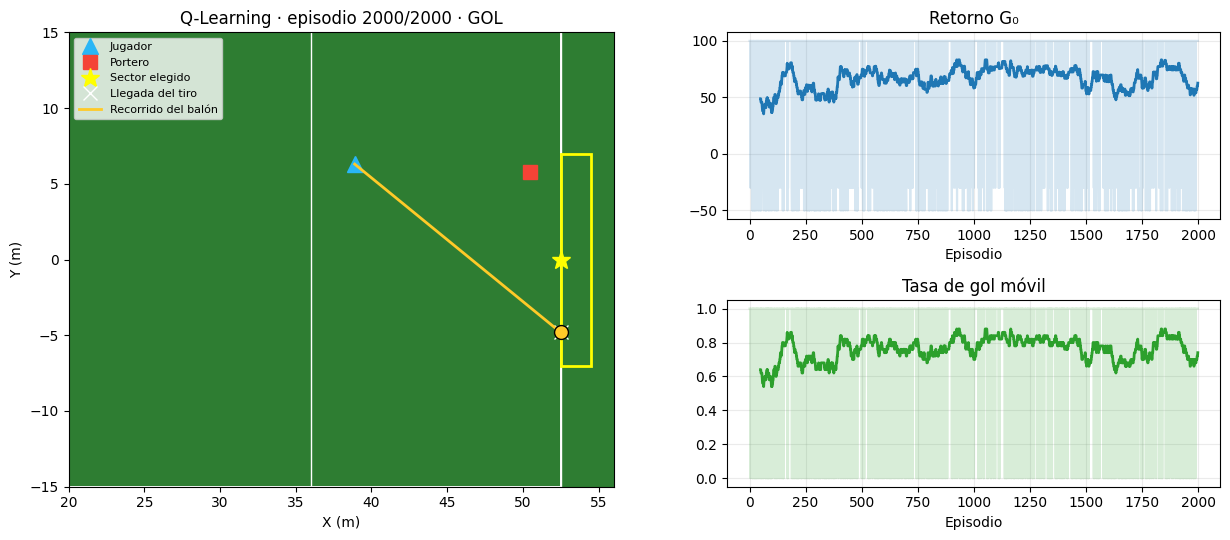

In [9]:
N_EPISODES = 2000
results = {}
for goalkeeper_active in (False, True):
    for algorithm in ALGORITHMS:
        for epsilon_mode in ("constant", "decay"):
            np.random.seed(42)
            env = GoalShootingSimEnv(goalkeeper_active=goalkeeper_active)
            options = dict(
                env=env,
                algorithm=algorithm,
                n_episodes=N_EPISODES,
                epsilon_mode=epsilon_mode,
            )
            if goalkeeper_active and epsilon_mode == "decay":
                Q, history = train_visual(render_every=500, **options)
            else:
                Q, history = train_control(**options)
            results[(goalkeeper_active, algorithm, epsilon_mode)] = (Q, history)

## 4. Retorno y tasa de conversión

La evaluación usa una política greedy sin actualizar Q. Se informa el promedio de los últimos 100 episodios de entrenamiento y la conversión de 500 disparos nuevos. Los pasos por episodio son siempre 1 y no se usan como curva de aprendizaje.


In [ ]:
def evaluate_policy(Q, goalkeeper_active, n_episodes=500, seed=2026):
    np.random.seed(seed)
    env = GoalShootingSimEnv(goalkeeper_active=goalkeeper_active)
    successes = 0
    for _ in range(n_episodes):
        state = env.reset()
        values = Q.get(state)
        if values is None or not np.any(values):
            action = int(np.random.randint(len(env.powers) * len(env.target_sectors)))
        else:
            action = int(np.argmax(values))
        _, _, _, info = env.step(action)
        successes += info["goal"]
    return successes / n_episodes


summary_rows = []
for (goalkeeper_active, algorithm, epsilon_mode), (Q, history) in results.items():
    summary_rows.append(
        {
            "Escenario": "Portero activo" if goalkeeper_active else "Arco abierto",
            "Algoritmo": ALGORITHM_NAMES[algorithm],
            "Exploración": epsilon_mode,
            "G₀ final (100)": round(float(np.mean(history["g0"][-100:])), 2),
            "Gol final (100) %": round(100 * np.mean(history["success"][-100:]), 1),
            "Gol greedy (500) %": round(100 * evaluate_policy(Q, goalkeeper_active), 1),
        }
    )
display(pd.DataFrame(summary_rows))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, goalkeeper_active in enumerate((False, True)):
    for mode, color in (("constant", "#1f77b4"), ("decay", "#d62728")):
        _, history = results[(goalkeeper_active, "mc", mode)]
        for col, key in enumerate(("g0", "success")):
            average = moving_average(history[key])
            axes[row, col].plot(
                range(len(history[key]) - len(average), len(history[key])),
                average,
                label=f"ε {mode}",
                color=color,
            )
    axes[row, 0].set_ylabel("Portero activo" if goalkeeper_active else "Arco abierto")
    axes[row, 0].set_title("Retorno G₀ · Monte Carlo")
    axes[row, 1].set_title("Tasa de gol móvil · Monte Carlo")
    axes[row, 1].set_ylim(0, 1)
for ax in axes.flat:
    ax.set_xlabel("Episodio")
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()
plt.show()

## 5. Política y valor por estado observado

El mapa usa la política de Monte Carlo con exploración decreciente y portero activo. Muestra distancia al arco frente a zona del portero, fijando los dos ángulos en la pareja más frecuente del entrenamiento. Las celdas grises no se observaron: no se les asigna una política aprendida.


In [ ]:
Q_map, history_map = results[(True, "mc", "decay")]
angle_pair = Counter((s[1], s[2]) for s in history_map["states"]).most_common(1)[0][0]
values = np.full((4, 4), np.nan)
actions = np.full((4, 4), -1, dtype=int)
for (distance_bin, left_bin, right_bin, goalkeeper_bin), q_values in Q_map.items():
    if (left_bin, right_bin) == angle_pair:
        values[distance_bin, goalkeeper_bin] = q_values.max()
        actions[distance_bin, goalkeeper_bin] = int(np.argmax(q_values))

fig, (ax_value, ax_policy) = plt.subplots(1, 2, figsize=(11, 4.5))
cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("#dddddd")
image = ax_value.imshow(values, cmap=cmap, aspect="auto")
fig.colorbar(image, ax=ax_value, label="V(s) = max Q(s,a)")
ax_value.set_title("Valor de estados observados")
ax_policy.imshow(actions, cmap="tab10", vmin=0, vmax=8, aspect="auto")
ax_policy.set_title("Acción greedy: potencia / sector")
for row in range(4):
    for col in range(4):
        if actions[row, col] >= 0:
            action = actions[row, col]
            label = f"{(50, 75, 100)[action // 3]}/{('I', 'C', 'D')[action % 3]}"
            ax_policy.text(col, row, label, ha="center", va="center", fontsize=9)
for ax in (ax_value, ax_policy):
    ax.set_xticks(range(4), ("Sin portero", "Izq.", "Centro", "Der."))
    ax.set_yticks(range(4), ("<15", "15–25", "25–35", ">=35"))
    ax.set_xlabel("Sector del portero")
    ax.set_ylabel("Distancia al arco (m)")
fig.suptitle(f"Ángulos fijos: izquierdo={angle_pair[0]}, derecho={angle_pair[1]}")
fig.tight_layout()
plt.show()

## 6. Resultados por acción

En este MDP de un paso, el objetivo de actualización de Monte Carlo, SARSA, Expected SARSA y Q-Learning es la misma recompensa observada. Por eso se muestra la frecuencia empírica de gol por potencia y sector, en vez de una comparación de sesgo de objetivos idénticos.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, goalkeeper_active in zip(axes, (False, True)):
    np.random.seed(2026)
    env = GoalShootingSimEnv(goalkeeper_active=goalkeeper_active)
    rates = np.zeros((3, 3))
    for action in range(9):
        goals = 0
        for _ in range(300):
            env.reset()
            _, _, _, info = env.step(action)
            goals += info["goal"]
        rates[action // 3, action % 3] = goals / 300
    image = ax.imshow(rates, cmap="YlGn", vmin=0, vmax=1)
    ax.set_title("Portero activo" if goalkeeper_active else "Arco abierto")
    ax.set_xticks(range(3), ("Izquierda", "Centro", "Derecha"))
    ax.set_yticks(range(3), ("50", "75", "100"))
    ax.set_xlabel("Sector")
    ax.set_ylabel("Potencia")
    for row in range(3):
        for col in range(3):
            ax.text(col, row, f"{rates[row, col]:.0%}", ha="center", va="center")
fig.colorbar(image, ax=axes, shrink=0.8, label="Tasa de gol")
plt.show()

## 7. Dos disparos desde la misma posición

Se compara una acción aleatoria con la acción greedy aprendida. Se conserva el mismo jugador, orientación y portero para ambos tiros. Las líneas representan la interpolación visual entre el punto inicial y el resultado que devuelve el entorno.


In [ ]:
np.random.seed(2026)
env_compare = GoalShootingSimEnv(goalkeeper_active=True)
state = env_compare.reset()
start = (
    env_compare.player_x,
    env_compare.player_y,
    env_compare.player_theta,
    env_compare.goalkeeper_x,
    env_compare.goalkeeper_y,
)
noise_state = np.random.get_state()
Q_compare = results[(True, "mc", "decay")][0]
greedy_values = Q_compare.get(state)
greedy_action = int(np.argmax(greedy_values)) if greedy_values is not None else 1
actions_to_compare = (int(np.random.default_rng(2026).integers(9)), greedy_action)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, action, title in zip(axes, actions_to_compare, ("Aleatorio", "Greedy")):
    (
        env_compare.player_x,
        env_compare.player_y,
        env_compare.player_theta,
        env_compare.goalkeeper_x,
        env_compare.goalkeeper_y,
    ) = start
    env_compare.done = False
    np.random.set_state(noise_state)
    _, reward, _, info = env_compare.step(action)
    draw_shot(ax, env_compare, info, action)
    end_x, end_y = shot_endpoint(env_compare, info)
    ax.plot(
        [env_compare.player_x, end_x],
        [env_compare.player_y, end_y],
        color="#ffca28",
        linewidth=2,
    )
    ax.plot(end_x, end_y, "o", color="#ffca28", markeredgecolor="black")
    ax.set_title(f"{title}: {info['result']} · recompensa {reward:+.0f}")
fig.tight_layout()
plt.show()

## 8. Alcance de la conexión con RoboCup

Los resultados anteriores pertenecen a `GoalShootingSimEnv`. El cliente UDP del repositorio todavía no proporciona todas las observaciones necesarias para ejecutar esta política en `rcssserver` (en particular, postes y portero). Una conexión al servidor por sí sola no valida la tasa de gol obtenida aquí. La prueba de Docker y la ejecución del notebook quedan pendientes.
